In [1]:
!pip install -q vaderSentiment transformers torch datasets accelerate scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.1 MB/s eta 0:00:00


## Section 1 — Load & EDA

In [2]:
import pandas as pd
import ast
import re
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Load từ Google Sheets
SHEET_ID = '1KXcA0PPOpygla1inEfnTc10FND6DFNL8p8vpQKAX6Tw'
url = f'https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv'
df = pd.read_csv(url)

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nDtypes:\n{df.dtypes}')
df.head(5)

Shape: (4000, 6)

Columns: ['parent_asin', 'sentence_id', 'sentence_text', 'rating', 'triplets', 'category_name']

Dtypes:
parent_asin       object
sentence_id        int64
sentence_text     object
rating           float64
triplets          object
category_name     object
dtype: object


,parent_asin,sentence_id,sentence_text,rating,triplets,category_name
0,B07DGRVTWF,3,basically a poor implementation of the alexa p...,2.0,"[[""alexa platform"", ""poor implementation"", 0]]",electronics_p2
1,B07BFPJ6VX,4,support through direct messaging was great no ...,5.0,"[[""support through direct messaging"", ""great"",...",electronics_p2
2,B0B1PYNH8X,1,for echo show 5 i have the 2nd generation echo...,5.0,[],electronics_p2
3,B0007X9JMA,4,br br note i ve only used it for regular compu...,5.0,[],electronics_p2
4,B00N63V39K,6,wanted to use for business but i m in sales an...,1.0,[],electronics_p2


In [3]:
# Loại bỏ tag [GENERIC_NOUN], <br>, br br, và dọn khoảng trắng
def clean_text(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r'\[GENERIC_NOUN\]', '', text)
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'\bbr\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['sentence_text'] = df['sentence_text'].apply(clean_text)
df[['sentence_text']].head(10)

,sentence_text
0,basically a poor implementation of the alexa p...
1,support through direct messaging was great no ...
2,for echo show 5 i have the 2nd generation echo...
3,note i ve only used it for regular computer wo...
4,wanted to use for business but i m in sales an...
5,i use it everyday to backup important files
6,as well as occasional book reading and online ...
7,the other major con is that it does not shut d...
8,i ve bought other screen protectors thatsay go...
9,i like this ipad cover i like this ipad cover


In [ ]:
def parse_triplets(val):
    try:
        result = ast.literal_eval(str(val))
        return result if isinstance(result, list) else []
    except:
        return []

df['triplets_parsed'] = df['triplets'].apply(parse_triplets)
df['n_triplets'] = df['triplets_parsed'].apply(len)

has_triplets = df['n_triplets'] > 0

Tổng số triplets: 3842

Phân phối sentiment:
  0 (negative): 1188 (30.9%)
  1 (neutral): 173 (4.5%)
  2 (positive): 2481 (64.6%)


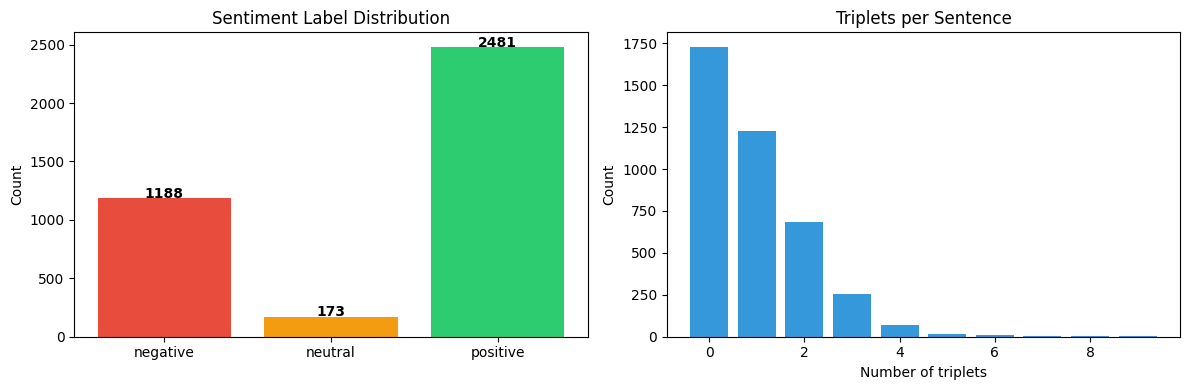

In [5]:
# Phân phối sentiment labels
all_triplets = [t for triplets in df['triplets_parsed'] for t in triplets]
sentiments = [int(t[2]) for t in all_triplets if len(t) >= 3]
sentiment_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

sentiment_counts = Counter(sentiments)
print(f'Tổng số triplets: {len(all_triplets)}')
print(f'\nPhân phối sentiment:')
for k, v in sorted(sentiment_counts.items()):
    print(f'  {k} ({sentiment_map.get(k, k)}): {v} ({v/len(sentiments)*100:.1f}%)')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = [sentiment_map.get(k, str(k)) for k in sorted(sentiment_counts.keys())]
counts = [sentiment_counts[k] for k in sorted(sentiment_counts.keys())]
colors = ['#e74c3c', '#f39c12', '#2ecc71']
axes[0].bar(labels, counts, color=colors[:len(labels)])
axes[0].set_title('Sentiment Label Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

triplet_dist = df['n_triplets'].value_counts().sort_index()
axes[1].bar(triplet_dist.index, triplet_dist.values, color='#3498db')
axes[1].set_title('Triplets per Sentence')
axes[1].set_xlabel('Number of triplets')
axes[1].set_ylabel('Count')

plt.tight_layout()
# plt.savefig('../outputs/reports/eda_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [6]:
# Top aspect terms
aspects = [t[0].lower().strip() for t in all_triplets if len(t) >= 1]
top_aspects = Counter(aspects).most_common(20)

print('Top 20 aspect terms:')
for aspect, count in top_aspects:
    print(f"  '{aspect}': {count}")

Top 20 aspect terms:
  'game': 155
  'book': 92
  'story': 73
  'app': 62
  'price': 49
  'it': 49
  'quality': 44
  'sound': 40
  'characters': 38
  'sound quality': 25
  'colors': 24
  'value': 22
  'battery': 21
  'color': 21
  'series': 20
  'cable': 19
  'books': 18
  'ink': 18
  'program': 18
  'fit': 17


## Section 2 — Data Preprocessing

Chuyển từ format `(sentence, [triplets])` sang format flat `(sentence, aspect, sentiment)` để huấn luyện.

In [7]:
# Flatten triplets
rows = []
for _, row in df.iterrows():
    for triplet in row['triplets_parsed']:
        if len(triplet) < 3:
            continue
        aspect, opinion, sentiment = triplet[0], triplet[1], triplet[2]
        rows.append({
            'parent_asin': row['parent_asin'],
            'sentence_text': row['sentence_text'],
            'aspect': str(aspect).lower().strip(),
            'opinion': str(opinion).lower().strip(),
            'sentiment': int(sentiment),
        })

df_asc = pd.DataFrame(rows)

# Cũng clean tag trong aspect và opinion
df_asc['aspect'] = df_asc['aspect'].apply(clean_text)
df_asc['opinion'] = df_asc['opinion'].apply(clean_text)

# Giữ nguyên 3 class
label_names = ['negative', 'neutral', 'positive']
num_labels = 3

df_asc['sentiment_label'] = df_asc['sentiment'].map({i: l for i, l in enumerate(label_names)})
df_asc['input_text'] = df_asc['sentence_text'] + ' [SEP] ' + df_asc['aspect']

print(f'Số rows sau flatten: {len(df_asc)}')
print(f'Số class: {num_labels} — {label_names}')
print(f'\nPhân phối sentiment:')
print(df_asc['sentiment_label'].value_counts())
df_asc.head(5)

Số rows sau flatten: 3842
Số class: 3 — ['negative', 'neutral', 'positive']

Phân phối sentiment:
sentiment_label
positive    2481
negative    1188
neutral      173
Name: count, dtype: int64


,parent_asin,sentence_text,aspect,opinion,sentiment,sentiment_label,input_text
0,B07DGRVTWF,basically a poor implementation of the alexa p...,alexa platform,poor implementation,0,negative,basically a poor implementation of the alexa p...
1,B07BFPJ6VX,support through direct messaging was great no ...,support through direct messaging,great,2,positive,support through direct messaging was great no ...
2,B07BFPJ6VX,support through direct messaging was great no ...,support through direct messaging,no language barrier,2,positive,support through direct messaging was great no ...
3,B07BFPJ6VX,support through direct messaging was great no ...,support through direct messaging,very responsive,2,positive,support through direct messaging was great no ...
4,B00G6SQJ46,i like this ipad cover i like this ipad cover,ipad cover,like,2,positive,i like this ipad cover i like this ipad cover ...


## Section 3 — Train/Test Split 


In [8]:
from sklearn.model_selection import train_test_split

df_with_triplets = df[df['n_triplets'] > 0].copy()

def majority_sentiment(triplets):
    labels = [int(t[2]) for t in triplets if len(t) >= 3]
    return max(set(labels), key=labels.count) if labels else 2

df_with_triplets['majority_sentiment'] = df_with_triplets['triplets_parsed'].apply(majority_sentiment)

trainval_sents, test_sents = train_test_split(
    df_with_triplets,
    test_size=0.10,
    random_state=42,
    shuffle=True,
    stratify=df_with_triplets['majority_sentiment']
)

train_sents, val_sents = train_test_split(
    trainval_sents,
    test_size=0.111,
    random_state=42,
    shuffle=True,
    stratify=trainval_sents['majority_sentiment']
)

print(f'Tổng câu có triplets: {len(df_with_triplets)}')
print(f'  Câu train: {len(train_sents)} | Câu val: {len(val_sents)} | Câu test: {len(test_sents)}')

Tổng câu có triplets: 2271
  Câu train: 1816 | Câu val: 227 | Câu test: 228


In [9]:
def flatten_sentences(df_sents):
    rows = []
    for _, row in df_sents.iterrows():
        for triplet in row['triplets_parsed']:
            if len(triplet) < 3:
                continue
            aspect, opinion, sentiment = triplet[0], triplet[1], int(triplet[2])
            rows.append({
                'parent_asin':   row['parent_asin'],
                'sentence_text': row['sentence_text'],
                'aspect':        clean_text(str(aspect).lower().strip()),
                'opinion':       clean_text(str(opinion).lower().strip()),
                'sentiment':     sentiment,
            })
    result = pd.DataFrame(rows)
    result['sentiment_label'] = result['sentiment'].map({i: l for i, l in enumerate(label_names)})
    result['input_text'] = result['sentence_text'] + ' [SEP] ' + result['aspect']
    return result

train_df = flatten_sentences(train_sents)
val_df   = flatten_sentences(val_sents)
test_df  = flatten_sentences(test_sents)

print(f'Sau flatten:')
print(f'  Triplets train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}')
print(f'\nPhân phối sentiment trong TRAIN:')
print(train_df['sentiment_label'].value_counts())
print(f'\nPhân phối sentiment trong VAL:')
print(val_df['sentiment_label'].value_counts())
print(f'\nPhân phối sentiment trong TEST:')
print(test_df['sentiment_label'].value_counts())

Sau flatten:
  Triplets train: 3060 | val: 388 | test: 394

Phân phối sentiment trong TRAIN:
sentiment_label
positive    1973
negative     948
neutral      139
Name: count, dtype: int64

Phân phối sentiment trong VAL:
sentiment_label
positive    255
negative    118
neutral      15
Name: count, dtype: int64

Phân phối sentiment trong TEST:
sentiment_label
positive    253
negative    122
neutral      19
Name: count, dtype: int64


In [10]:
import os
os.makedirs('../outputs/reports', exist_ok=True)

train_df.to_parquet('../outputs/asc_train.parquet', index=False)
test_df.to_parquet('../outputs/asc_test.parquet', index=False)

## Section 4 — Baseline: VADER + Context Window

In [11]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report, accuracy_score

analyzer = SentimentIntensityAnalyzer()

def vader_predict(row):
    sentence = row['sentence_text']
    aspect = row['aspect']
    idx = sentence.lower().find(aspect.lower())
    if idx >= 0:
        start = max(0, idx - 60)
        end = min(len(sentence), idx + len(aspect) + 60)
        context = sentence[start:end]
    else:
        context = sentence
    compound = analyzer.polarity_scores(context)['compound']
    if num_labels == 2:
        return 1 if compound >= 0.05 else 0
    else:
        if compound >= 0.05:
            return 2
        elif compound <= -0.05:
            return 0
        else:
            return 1

test_df['pred_vader'] = test_df.apply(vader_predict, axis=1)
y_true = test_df['sentiment']
y_pred_vader = test_df['pred_vader']

print('VADER Baseline:')
print(f'Accuracy: {accuracy_score(y_true, y_pred_vader):.4f}')
print(classification_report(y_true, y_pred_vader, target_names=label_names))

VADER Baseline:
Accuracy: 0.6802
              precision    recall  f1-score   support

    negative       0.72      0.40      0.52       122
     neutral       0.07      0.26      0.12        19
    positive       0.83      0.85      0.84       253

    accuracy                           0.68       394
   macro avg       0.54      0.50      0.49       394
weighted avg       0.76      0.68      0.70       394



## Section 5 — TF-IDF + Logistic Regression

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X_train = train_df['input_text']
y_train = train_df['sentiment']
X_test  = test_df['input_text']

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=20000, sublinear_tf=True)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
test_df['pred_lr'] = y_pred_lr

print('TF-IDF + Logistic Regression:')
print(f'Accuracy: {accuracy_score(y_true, y_pred_lr):.4f}')
print(classification_report(y_true, y_pred_lr, target_names=label_names))

TF-IDF + Logistic Regression:
Accuracy: 0.7386
              precision    recall  f1-score   support

    negative       0.60      0.71      0.65       122
     neutral       0.25      0.05      0.09        19
    positive       0.83      0.80      0.82       253

    accuracy                           0.74       394
   macro avg       0.56      0.52      0.52       394
weighted avg       0.73      0.74      0.73       394



## Section 6 — DeBERTa + Sentiment Classification


In [13]:
import torch
import numpy as np
from torch import nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

device = 'cuda'
print(f'Device: {device}')

MODEL_NAME = 'microsoft/deberta-v3-base'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

model = model.float()

print(f'\nLoaded: {MODEL_NAME} (num_labels={num_labels})')

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias        


Loaded: microsoft/deberta-v3-base (num_labels=3)


In [14]:
# Tokenize
def tokenize_fn(examples):
    return tokenizer(
        examples['input_text'],
        truncation=True,
        padding='max_length',
        max_length=256
    )

train_dataset = Dataset.from_pandas(train_df[['input_text', 'sentiment']].rename(columns={'sentiment': 'label'}))
val_dataset   = Dataset.from_pandas(val_df[['input_text', 'sentiment']].rename(columns={'sentiment': 'label'}))
test_dataset  = Dataset.from_pandas(test_df[['input_text', 'sentiment']].rename(columns={'sentiment': 'label'}))

train_dataset = train_dataset.map(tokenize_fn, batched=True, remove_columns=['input_text'])
val_dataset   = val_dataset.map(tokenize_fn, batched=True, remove_columns=['input_text'])
test_dataset  = test_dataset.map(tokenize_fn, batched=True, remove_columns=['input_text'])

train_dataset.set_format('torch')
val_dataset.set_format('torch')
test_dataset.set_format('torch')

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Map:   0%|          | 0/3060 [00:00<?, ? examples/s]

Map:   0%|          | 0/388 [00:00<?, ? examples/s]

Map:   0%|          | 0/394 [00:00<?, ? examples/s]

Train: 3060 | Val: 388 | Test: 394


In [15]:
# Class weights cho imbalanced data
class_weights = compute_class_weight(
    'balanced',
    classes=np.arange(num_labels),
    y=train_df['sentiment'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f'Class weights: {dict(zip(label_names, class_weights.round(3)))}')

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
    }

Class weights: {'negative': np.float64(1.076), 'neutral': np.float64(7.338), 'positive': np.float64(0.517)}


In [16]:
training_args = TrainingArguments(
    output_dir='../outputs/deberta_asc',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=20,
    fp16=False,
    bf16=False,
    report_to='none',
    save_total_limit=2,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.806163,0.866261,0.817010,0.546073
2,0.733972,0.920800,0.827320,0.552148
3,0.678651,0.961268,0.811856,0.607459
4,0.362310,1.133827,0.847938,0.568546
5,0.380512,1.046413,0.835052,0.642119


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=960, training_loss=0.6226799190044403, metrics={'train_runtime': 1163.296, 'train_samples_per_second': 13.152, 'train_steps_per_second': 0.825, 'total_flos': 2012853742848000.0, 'train_loss': 0.6226799190044403, 'epoch': 5.0})

In [17]:
# Evaluate DeBERTa trên test set
predictions = trainer.predict(test_dataset)
y_pred_deberta = np.argmax(predictions.predictions, axis=-1)
test_df['pred_deberta'] = y_pred_deberta

print('DeBERTa:')
print(f'Accuracy: {accuracy_score(y_true, y_pred_deberta):.4f}')
print(classification_report(y_true, y_pred_deberta, target_names=label_names))

DeBERTa:
Accuracy: 0.8807
              precision    recall  f1-score   support

    negative       0.82      0.88      0.85       122
     neutral       0.33      0.32      0.32        19
    positive       0.96      0.92      0.94       253

    accuracy                           0.88       394
   macro avg       0.70      0.71      0.70       394
weighted avg       0.88      0.88      0.88       394



## Section 7 — Evaluation & So sánh

In [18]:
from sklearn.metrics import f1_score, confusion_matrix

models = {
    'VADER Baseline':    y_pred_vader,
    'TF-IDF + LR':      y_pred_lr,
    'DeBERTa (fine-tuned)': y_pred_deberta,
}

header = f"{'Model':<25} {'Accuracy':>10} {'F1-macro':>10}"
for name in label_names:
    header += f" {'F1-'+name:>12}"
print(header)

results_summary = {}
for name, preds in models.items():
    acc = accuracy_score(y_true, preds)
    f1m = f1_score(y_true, preds, average='macro')
    f1_per_class = f1_score(y_true, preds, average=None, labels=list(range(num_labels)))
    f1_dict = {lbl: f1_per_class[i] for i, lbl in enumerate(label_names)}
    results_summary[name] = {'accuracy': acc, 'f1_macro': f1m, **{f'f1_{k}': v for k, v in f1_dict.items()}}
    row = f'{name:<25} {acc:>10.4f} {f1m:>10.4f}'
    for lbl in label_names:
        row += f' {f1_dict[lbl]:>12.4f}'
    print(row)

Model                       Accuracy   F1-macro  F1-negative   F1-neutral  F1-positive
VADER Baseline                0.6802     0.4893       0.5158       0.1163       0.8359
TF-IDF + LR                   0.7386     0.5177       0.6493       0.0870       0.8169
DeBERTa (fine-tuned)          0.8807     0.7033       0.8458       0.3243       0.9398


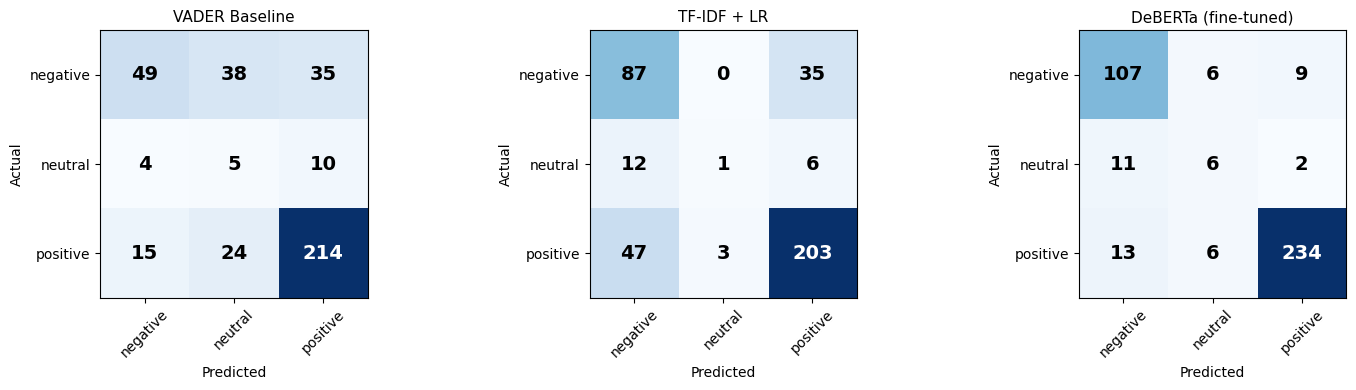

In [19]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_true, preds)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks(range(num_labels)); ax.set_xticklabels(label_names, rotation=45)
    ax.set_yticks(range(num_labels)); ax.set_yticklabels(label_names)
    for i in range(num_labels):
        for j in range(num_labels):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black',
                    fontsize=14, fontweight='bold')

plt.tight_layout()
# plt.savefig('../outputs/reports/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

In [20]:
# Error analysis: DeBERTa sai ở đâu?
errors = test_df[test_df['pred_deberta'] != test_df['sentiment']][
    ['sentence_text', 'aspect', 'sentiment_label', 'pred_deberta']
].copy()
errors['pred_label'] = errors['pred_deberta'].map({i: l for i, l in enumerate(label_names)})

print(f'Số lỗi của DeBERTa: {len(errors)}/{len(test_df)}')
print('\nCác trường hợp sai:')
for _, row in errors.head(15).iterrows():
    print(f"  Sentence : {row['sentence_text'][:90]}")
    print(f"  Aspect   : {row['aspect']}")
    print(f"  True     : {row['sentiment_label']}  |  Predicted: {row['pred_label']}")
    print()

Số lỗi của DeBERTa: 47/394

Các trường hợp sai:
  Sentence : beautiful puzzles only is that with the last update it has not been saving my puzzle progr
  Aspect   : puzzles
  True     : positive  |  Predicted: negative

  Sentence : my biggest gripe with other cables is that the housing is so big it prevents complete plug
  Aspect   : sound quality
  True     : positive  |  Predicted: negative

  Sentence : its back keypad is awesome and only draw back is its not that robust
  Aspect   : keypad
  True     : negative  |  Predicted: positive

  Sentence : all parental controls to prevent this are check marked yet it still happens
  Aspect   : parental controls
  True     : positive  |  Predicted: negative

  Sentence : i never checked the actual hours of battery life but i usually charge the to full completi
  Aspect   : battery life
  True     : positive  |  Predicted: neutral

  Sentence : the steps are super easy to follow along with even for the worst artist around
  Aspect   : artis